# 309.2. Extendedness parameter

<div style="max-width:300px; float: left; margin-right: 1em">

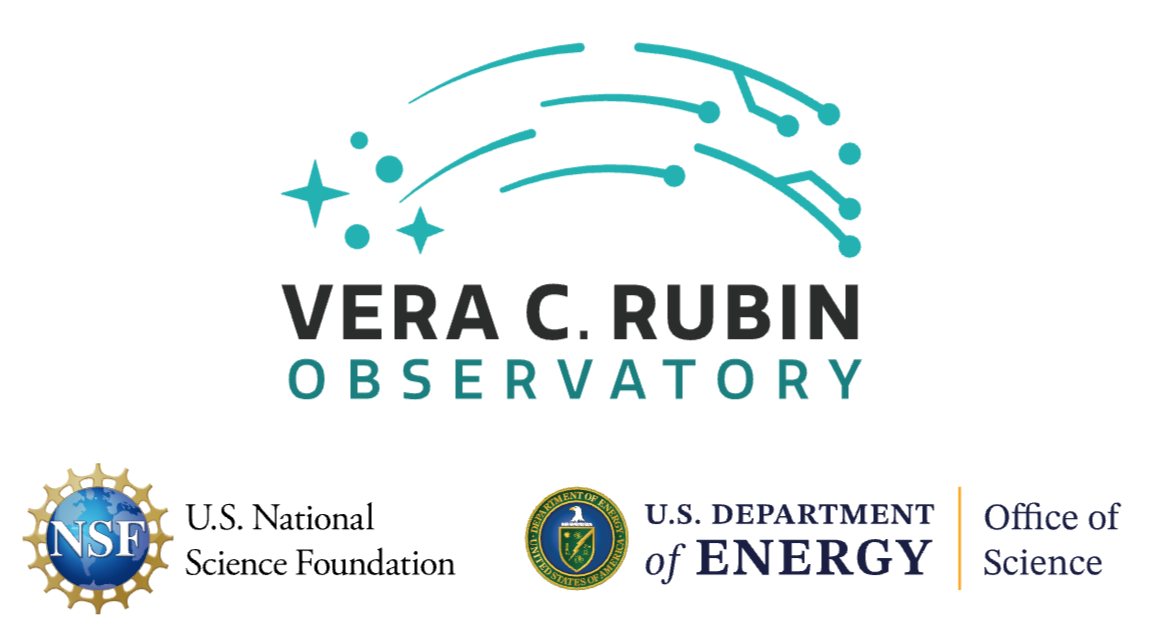

</div>

For the Rubin Science Platform at data.lsst.cloud.\
Data Release: [Data Preview 1](https://dp1.lsst.io)\
Container Size: large\
LSST Science Pipelines version: r29.2.0\
Last verified to run: 2026-01-12\
Repository: [github.com/lsst/tutorial-notebooks](https://github.com/lsst/tutorial-notebooks)\
DOI: [10.11578/rubin/dc.20250909.20](https://doi.org/10.11578/rubin/dc.20250909.20)

**Learning objective:** To explore the extendedness parameter.

**LSST data products:** `Object`

**Packages:** `lsst.rsp`

**Credit:**
Originally developed by the Rubin Community Science team. Please consider acknowledging them if this notebook is used for the preparation of journal articles, software releases, or other notebooks.

**Get Support:**
Everyone is encouraged to ask questions or raise issues in the 
<a href="https://community.lsst.org/c/support">Support Category</a> 
of the Rubin Community Forum.
Rubin staff will respond to all questions posted there.

## 1. Introduction

In astronomical imaging surveys like LSST, classifying sources as either point-like (stars) or extended (galaxies) is a fundamental step in data analysis. In Data Preview 1 (DP1), this classification is primarily handled by the `extendedness` parameter. This tutorial demonstrates how this parameter was computed and the specific caveats noted in the [RTN-095](https://rtn-095.lsst.io/) technical note.

The LSST Science Pipelines distinguish stars from galaxies by comparing two different flux measurements for every detected object:
- PSF Flux: The flux measured by fitting the Point Spread Function (PSF) model to the source. This model assumes the source is unresolved.
- CModel Flux: The flux measured by fitting a "Composite Model". This model allows for the source to be extended.

The classification logic relies on the ratio of these two fluxes. For a star, the object is unresolved, meaning the PSF flux captures the same amount of light as the composite model, and the ratio is close to unity. For a galaxy, the object is extended, so the PSF fit fails to capture flux in the wings, causing the PSF flux to be significantly lower than the CModel flux. The pipeline applies a configurable threshold to this ratio to assign a **binary** flag. If the ratio PSF Flux/CModel Flux is greater than or equal to 0.985, the `extendedness` parameter is set to 0, indicating a star. Conversely, if the ratio is less than 0.985, the parameter is set to 1, indicating a galaxy.

However, users must be aware of critical limitations in the DP1 dataset as highlighted in RTN-095. The binary classification becomes unreliable at faint magnitudes (specifically $r$>24), where the "unresolved" sample suffers from increasing contamination by galaxies due to decreasing signal-to-noise ratios. Additionally, while the `Object` table provides `extendedness` values for every individual filter, it is strongly recommended to use `refExtendedness` for most science cases. This value is derived from the designated reference band (typically the band with the best seeing or depth), ensuring a single, robust classification for each object.

describe how the extendedness parameter (and any related flags) are computed
characterize the extendedness parameter
where it does well, where it fails, use color/color space and other object characteristics

**Related tutorials:** 

### 1.1. Import packages

Import `numpy`, a fundamental package for scientific computing with arrays in Python
(<a href="https://numpy.org">numpy.org</a>), 
and `matplotlib`, a comprehensive library for data visualization
(<a href="https://matplotlib.org/">matplotlib.org</a>;
<a href="https://matplotlib.org/stable/gallery/index.html">matplotlib gallery</a>).

From the LSST pacakge (<a href="https://pipelines.lsst.io/">pipelines.lsst.io</a>), import the RSP Table Access Protocol (TAP) service. Also import the `DustValues` class from the `rubin_sim` package (<a href="https://rubin-sim.lsst.io/index.html">rubin_sim</a>).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from astropy import units as u
from astropy.coordinates import SkyCoord
import os

from lsst.rsp import get_tap_service
from rubin_sim.phot_utils import DustValues

### 1.2. Define parameters and functions

Create an instance of the TAP service, and assert that it exists.

In [2]:
rsp_tap = get_tap_service("tap")
assert rsp_tap is not None

Define a 1-degree radius around the central point of the 47 Tuc field.

In [3]:
ra_cen = 6.128
dec_cen = -72.090
radius = 1.0

List bands available in the field.

In [4]:
bands = "griy"

Set the environment variable `RUBIN_SIM_DATA_DIR` to `/rubin/rubin_sim_data` to make the current `rubin_sim` throughput data available.

In [5]:
os.environ['RUBIN_SIM_DATA_DIR'] = '/rubin/rubin_sim_data'

Set font sizes globally for all subsequent matplotlib figures in this notebook.

In [6]:
plt.rcParams["font.size"] = 15
plt.rcParams["figure.titlesize"] = 15
plt.rcParams["legend.fontsize"] = 12
plt.rcParams["axes.titlesize"] = 12

## 2. Explore extendedness parameter

The `Object` table contains forced photometric measurements on the deep coadded images at the locations of all objects detected with signal-to-noise ratio > 5 in a `deep_coadd` of any filter, as well as corresponding E(B-V) values from the SFD98 dust map (`ebv` column).

### 2.1. Query `Object` table

Query the `Object` table for coordinates, photometric measurements, extendedness parameter, and E(B-V) values.

In [7]:
query = f"""SELECT coord_ra, coord_dec,
        g_psfMag, r_psfMag, i_psfMag, y_psfMag,
        g_psfFlux, r_psfFlux, i_psfFlux, y_psfFlux,
        g_cModelMag, r_cModelMag, i_cModelMag, y_cModelMag,
        g_cModelFlux, r_cModelFlux, i_cModelFlux, y_cModelFlux,
        g_extendedness, r_extendedness, i_extendedness, y_extendedness,
        g_sizeExtendedness, r_sizeExtendedness, i_sizeExtendedness, y_sizeExtendedness,
        refExtendedness, ebv
        FROM dp1.Object
        WHERE CONTAINS(POINT('ICRS', coord_ra, coord_dec), 
              CIRCLE('ICRS', {ra_cen}, {dec_cen}, {radius})) = 1 
        """

In [8]:
job = rsp_tap.submit_job(query)
job.run()
job.wait(phases=['COMPLETED', 'ERROR'])
print('Job phase is', job.phase)
if job.phase == 'ERROR':
    job.raise_if_error()

Job phase is COMPLETED


Fetch the results and store them as a table.

In [9]:
assert job.phase == 'COMPLETED'
table = job.fetch_result().to_table()
print(f"The query returned {len(table)} objects.")

The query returned 115493 objects.


Option to display the table of results.

In [28]:
# table

### 2.2 Extendedness vs. Flux ratio

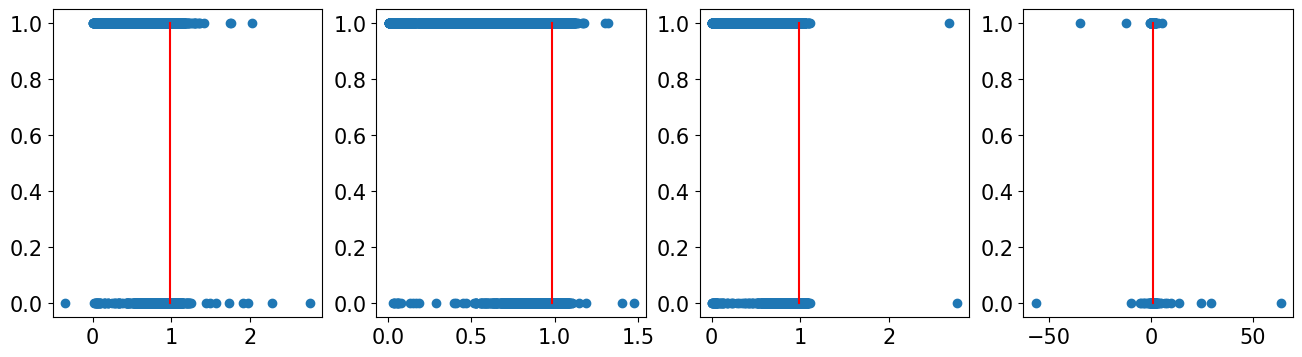

In [10]:
fig, axes = plt.subplots(1,4, figsize=(16, 4))

for band, ax in zip(bands, axes.flatten()):
    good_src = (table[f'{band}_psfFlux'] > 0) & (table[f'{band}_cModelFlux'] > 0)
    ax.scatter(table[f'{band}_psfFlux']/table[f'{band}_cModelFlux'],
               table[f'{band}_extendedness'])
    ax.plot([0.985, 0.985], [0, 1], 'r')

### 2.3. Extendedness per band

Explore the distribution of `extenededness` as a function of magnitude in each filter.

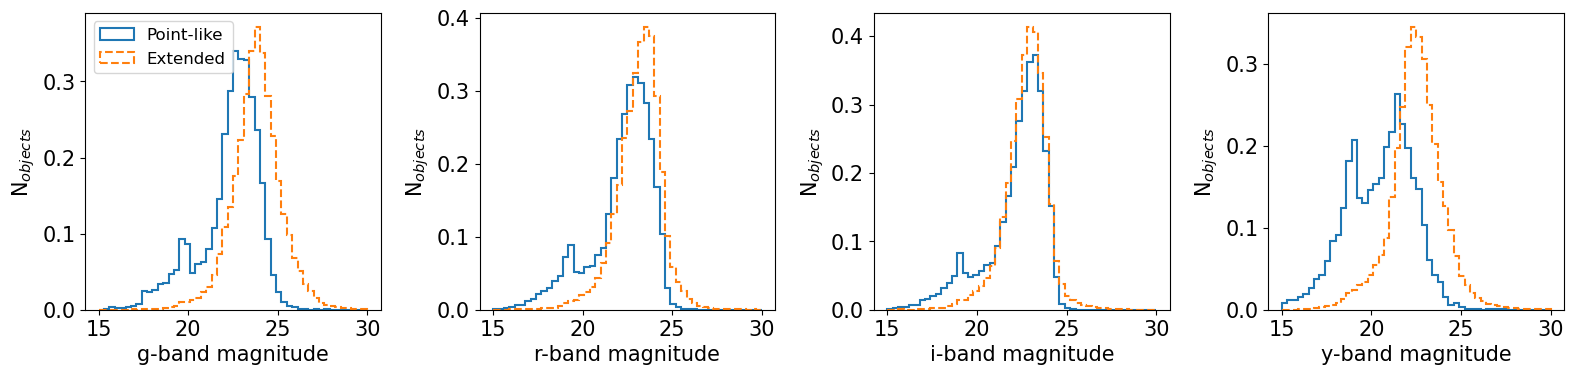

In [11]:
fig, axes = plt.subplots(1,4, figsize=(16, 4))

for band, ax in zip(bands, axes.flatten()):
    is_star = table[f'{band}_extendedness'] == 0
    
    ax.hist(
        table[f'{band}_psfMag'][is_star], 
        bins=50, range=(15, 30), density=True,
        histtype='step', linewidth=1.5,
        label='Point-like'
    )
    
    ax.hist(
        table[f'{band}_cModelMag'][~is_star], 
        bins=50, range=(15, 30), density=True,
        histtype='step', linestyle='--', linewidth=1.5,
        label='Extended'
    )
    
    ax.set_xlabel(f'{band}-band magnitude')
    ax.set_ylabel(r'N$_{objects}$')
    
    if band == 'g':
        ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

> **Figure 1:** Magnitude distributions for point-like (blue solid lines) and extended (orange dashed lines) sources in the $g,r,i$, and $y$ bands. Point sources are characterized by their `PSF` magnitudes, while extended sources use `cModel` magnitudes. The bright end of the distribution is dominated by point sources, while extended sources dominate at fainter magnitudes.

### 2.4. Extendedness vs. SizeExtendedness

Compare two different extendedness parameters. See how `SizeExtendedness` paramter was computed: https://github.com/lsst/meas_base/blob/main/python/lsst/meas/base/plugins.py#L683-L689.

**Slack conversation with Jim and Eli**
Jim: I voted against Eli on putting sizeExtendedness in object, because I don't think extendedness has really been tested all that much either, and I know it suffers from some garbage-in problems at the faint end.  It's been used for ages but nobody has done the work to say which is better.

Eli: But note that sizeExtendedness is a floating point value so you can adjust thresholds (unlike extendedness) sizeExtendedness is basically a likelihood measurement based on the HSM moments on the source and on the psf model, and comparing those. So if the HSM moment says that the source is similar in size to the PSF model at that location it has a higher likelihood of being a star.  And there’s an empirical scaling factor for seeing.

Jim: sizeExtendedness is measured the same way in both cases. flux-based extendedness is only potentially good for object. flux-based extendedness needs both a PSF flux input and a galaxy-model flux input.  We don't really run any galaxy modeling on the single-visit images, so any extendedness you see on source is from a poor substitute for a galaxy model flux.

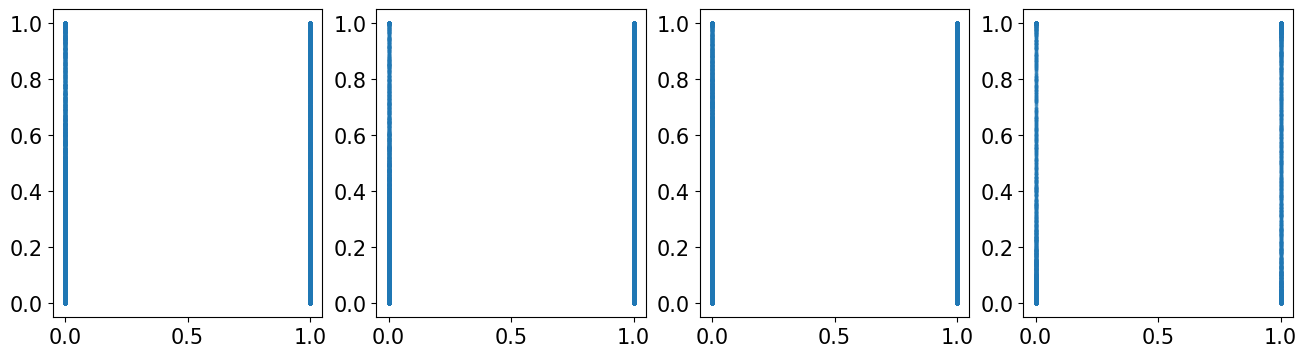

In [15]:
fig, axes = plt.subplots(1,4, figsize=(16, 4))

for band, ax in zip(bands, axes.flatten()):
    ax.scatter(table[f'{band}_extendedness'],
               table[f'{band}_sizeExtendedness'], s=3, alpha=0.2)
    # ax.plot([0.985, 0.985], [0, 1], 'r')

## 3. Correct the effects of dust

In `rubin_sim.phot_utils`, `DustValues().r_x` provides the $R_{\lambda}$ values for the Rubin filters. These values are calculated using the CCM89 extinction curve ([Cardelli, Clayton, and Mathis 1989](https://ui.adsabs.harvard.edu/abs/1989ApJ...345..245C/abstract)), assuming a *flat* spectral energy distribution. The default $R_{V}$ is 3.1 (for the Milky Way diffuse ISM), but it is possible to specify a different value with the keyword argument `r_v`.

Print out $R_{\lambda}$ values for $ugrizy$.

In [ ]:
R_band = DustValues().r_x
print(R_band)

### 3.1. Compute extinction

$E(B−V)$ sets the scale of dust along the line of sight, while $R_\lambda$, combined with an extinction curve, specifies the wavelength dependance. Together, extinction in a given band can be computed as: $A_\lambda = R_\lambda\times\,E(B-V)$. Apply this relation to compute extinction in each band.

In [ ]:
A_band = {band: R_band[band] * table['ebv'] for band in bands}

### 3.2. Apply extinction corrections

Apply extinction corrections to the observed magnitudes in each band ($m_{\lambda,0} = m_\lambda - A_\lambda$), and add the corrected magnitudes back into the table.

In [ ]:
for band in bands:
    table[f"{band}_psfMag0"] = table[f"{band}_psfMag"] - A_band[band]
    table[f"{band}_cModelMag0"] = table[f"{band}_cModelMag"] - A_band[band]

### 3.3. Compare magnitudes

Compare magnitudes before and after dust correction both for stars (i.e., `refExtendedness` = 0) and galaxies (i.e., `refExtendedness` = 1). 

In [ ]:
is_star = table['refExtendedness'] == 0
is_galaxy = table['refExtendedness'] == 1

bins = np.linspace(0, 0.3, 50)

fig, axes = plt.subplots(6, 2, figsize=(10, 18), sharex=True)
plt.subplots_adjust(wspace=0.25, hspace=0.35)

axes[0, 0].set_title("PSF (stars)")
axes[0, 1].set_title("cModel (galaxies)")

for i, b in enumerate(bands):
    m = table[f"{b}_psfMag"]
    m0 = table[f"{b}_psfMag0"]
    ok = is_star & np.isfinite(m) & np.isfinite(m0)
    dmag = np.asarray(m[ok]) - np.asarray(m0[ok])
    ax = axes[i, 0]
    ax.hist(dmag, bins=bins)
    med = np.median(dmag) if dmag.size else np.nan
    if np.isfinite(med):
        ax.axvline(med, c="r", linestyle="--")
        ax.text(0.98, 0.95, f"median = {med: .3f} mag",
                transform=ax.transAxes, ha="right", va="top")
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymax * 1.2)
    ax.set_ylabel(f"{b}-band count")

    m = table[f"{b}_cModelMag"]
    m0 = table[f"{b}_cModelMag0"]
    ok = is_galaxy & np.isfinite(m) & np.isfinite(m0)
    dmag = np.asarray(m[ok]) - np.asarray(m0[ok])
    ax = axes[i, 1]
    ax.hist(dmag, bins=bins)
    med = np.median(dmag) if dmag.size else np.nan
    if np.isfinite(med):
        ax.axvline(med, c="r", linestyle="--")
        ax.text(0.98, 0.95, f"median = {med: .3f} mag",
                transform=ax.transAxes, ha="right", va="top")
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymax * 1.2)

axes[-1, 0].set_xlabel(r"m - m$_{0}$ [mag]")
axes[-1, 1].set_xlabel(r"m - m$_{0}$ [mag]")

plt.tight_layout()
plt.show()

> **Figure 2:** Histograms of magnitude differences between observed and dust-corrected values for stars (left column, PSF magnitudes) and galaxies (right column, cModel magnitudes) in the $ugrizy$ bands. The median of each distribution is marked with a red dashed line, and its value is printed inside the panel. The differences are largest in the bluest $u$ band and decrease toward longer wavelengths, with the reddest $y$ band showing the smallest dust effect, independent of the photometric measurement (PSF vs. cModel).

## 4. Caveat for using the SFD98 map

The SFD98 map is uncertain and unreliable along sightlines with Galactic latitude |b| < 5$^{\circ}$ due to contamination in the 100 $\mu$m dust emission map. The Seagull Nebula lies within this zone. It also hosts newly formed stars and is an H II complex with hot, structured dust, conditions under which the SFD98 map is known to be biased. In addition, the map provides the full dust column to infinity, whereas much of the dust toward the Seagull Nebula is at only 1–2 kpc. In short, applying the SFD98 map to foreground stars or nearby H II regions leads to over-correction.

### 4.1. Retrieve Seagull Nebula data

Query the `Object` table for the Seagull Nebula field and examine the pitfalls of using the `ebv` column. First, define the field’s central position in ICRS equatorial coordinates, then convert it to Galactic coordinates to show that it lies very close to the Milky Way plane.

In [ ]:
ra_cen_seagull = 106.23
dec_cen_seagull = -10.51

c = SkyCoord(ra=ra_cen_seagull*u.degree, dec=dec_cen_seagull*u.degree,
             frame='icrs')
print(c.galactic)

Retrieve only the columns required to construct a $(g-r,\, g)$ color–magnitude diagram for stars in the Seagull Nebula field.

In [ ]:
query = f"""SELECT objectId, g_psfMag, r_psfMag, ebv
        FROM dp1.Object
        WHERE CONTAINS(POINT('ICRS', coord_ra, coord_dec), 
            CIRCLE('ICRS', {ra_cen_seagull}, {dec_cen_seagull}, {radius})) = 1
        AND refExtendedness = 0
        """

In [ ]:
job = rsp_tap.submit_job(query)
job.run()
job.wait(phases=['COMPLETED', 'ERROR'])
print('Job phase is', job.phase)
if job.phase == 'ERROR':
    job.raise_if_error()

In [ ]:
assert job.phase == 'COMPLETED'
table_seagull = job.fetch_result().to_table()
print(f'The query returned {len(table_seagull)} objects.')

### 4.2. Apply extinction correction

Repeat the procedures from Sections 3.1 and 3.2 to apply dust corrections to the Seagull Nebula field photometry, limiting the correction to the retrieved $g$ and $r$ bands.

In [ ]:
bands_seagull = "gr"
A_band = {band: R_band[band] * table_seagull['ebv'] for band in bands_seagull}

for band in bands_seagull:
    table_seagull[f"{band}_psfMag0"] = (
        table_seagull[f"{band}_psfMag"] - A_band[band]
    )

Compare the ($g-r$, $g$) color-magnitude diagram constructed from the observed photometry with that built from the dust-corrected photometry. 

In [ ]:
g_ok = np.isfinite(table_seagull["g_psfMag"])
r_ok = np.isfinite(table_seagull["r_psfMag"])
ok = g_ok & r_ok

g = table_seagull["g_psfMag"][ok]
r = table_seagull["r_psfMag"][ok]
g0 = table_seagull["g_psfMag0"][ok]
r0 = table_seagull["r_psfMag0"][ok]

fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)

h1 = axes[0].hist2d(
    g-r, g,
    range=[(-4, 4), (5, 30)],
    bins=200,
    norm=LogNorm()
)
axes[0].set_xlabel("g − r")
axes[0].set_ylabel("g")
axes[0].set_title("Observed")
axes[0].invert_yaxis()

h2 = axes[1].hist2d(
    g0-r0, g0,
    range=[(-4, 4), (5, 30)],
    bins=200,
    norm=LogNorm(vmax=h1[0].max())
)
axes[1].set_xlabel("g − r")
axes[1].set_title("Dust-corrected")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

> **Figure 3:** $(g-r,\, g)$ color–magnitude diagrams of the Seagull Nebula field using observed magnitudes (left) and dust-corrected magnitudes (right). The increased scatter in the stellar sequence demonstrates that the SFD98-based dust correction does not perform reliably for this field. While the average $E(B-V)$ value from the 2D SFD98 map agrees with the reddening reported by the 3D dust map at the distance of the Seagull Nebula ([Bayestar dust map](http://argonaut.skymaps.info/)), many individual values are significantly larger than expected from the 3D map.

## 5. Exercise for the learner

Apply dust correction with a different $R_{V}$ than the default 3.1 using the keyword argument `r_v` in `DustValues()`. Compare these photometry with those corrected with $R_{V}$ = 3.1 in Section 3.